In [1]:
# Cek versi node dan npm (Google Colab biasanya sudah terinstal otomatis)
!node -v
!npm -v

v24.14.1
11.11.0


In [3]:
import os

# Ganti tulisan MASUKKAN_AUTH_TOKEN_ANDA_DISINI dengan nilai auth_token Anda
twitter_auth_token = '234ce4e683b5091aa71b217908f8cef6f9cd848c' 
os.environ['TWITTER_AUTH_TOKEN'] = twitter_auth_token

# Konfigurasi pencarian (Keyword: genshin, Bahasa: id, Tahun: 2025-2026)
search_keyword = 'genshin lang:id since:2025-01-01 until:2026-06-09'
limit = 1000
filename = 'genshin_tweets.csv'

# Menjalankan Tweet-Harvest menggunakan versi terbaru (@latest)
!npx -y tweet-harvest@latest -o "{filename}" -s "{search_keyword}" -l {limit} --token {twitter_auth_token}

Tweet Harvest [v2.7.1]

Research by Helmi Satria
Use it for Educational Purposes only!

This script uses Chromium Browser to crawl data from Twitter with your Twitter auth token.
Please enter your Twitter auth token when prompted.

Note: Keep your access token secret! Don't share it with anyone else.
Note: This script only runs on your local device.


Opening twitter search page...


Filling in keywords: genshin lang:id since:2025-01-01 until:2026-06-09


-- Scrolling... (1)Created new directory: \\?\e:\Dokumen\Kuliah Teknik Informatika Udinus\Semester 6\Pemrosesan Bahasa Alami berbasis Teks\analisis-sentimen-genshin\tweets-data


Your tweets saved to: e:\Dokumen\Kuliah Teknik Informatika Udinus\Semester 6\Pemrosesan Bahasa Alami berbasis Teks\analisis-sentimen-genshin\tweets-data\genshin_tweets.csv
Total tweets saved: 0

-- Scrolling... (1) (2) (3) (4) (5) (6) (7) (8) (9) (10) (11) (12) (13) (14) (15) (16) (17) (18) (19) (20) (21)No more tweets found, please check your search criteria

In [6]:
import pandas as pd

# Secara default, Tweet-Harvest menyimpan file di dalam folder 'tweets-data'
filepath = f"tweets-data/genshin_tweets.csv"

try:
    df_tweets = pd.read_csv(filepath)
    print(f"Berhasil memuat {len(df_tweets)} tweet dari file {filepath}.")
    
    # Menampilkan 5 data teratas, fokus pada waktu, username, dan teks tweet
    display(df_tweets[['created_at', 'username', 'full_text']].head())
except FileNotFoundError:
    print("File CSV belum ditemukan. Pastikan proses crawling di atas berhasil dan auth_token Anda valid/tidak expired.")

Berhasil memuat 702 tweet dari file tweets-data/genshin_tweets.csv.


,created_at,username,full_text
0,2025-12-24T11:32:13.000Z,GenshinImpactID,#GenshinImpact #Arlecchino #Columbina #Sandron...
1,2025-12-26T13:10:03.000Z,babufess,"babu! gengs yg pernah beli pop mart genshin, i..."
2,2025-12-31T07:10:03.000Z,babufess,"babu! karena hari ini penghujung tahun 2025, a..."
3,2025-12-27T04:00:00.000Z,GenshinImpactID,#GenshinImpact \nAs Heaven and Earth Are Made ...
4,2025-12-29T13:45:10.000Z,babufess,"Babu! CW // LEAKS , LEAK\n\nKarakter ""kesayang..."


In [7]:
import re

def clean_tweet(text):
    # 1. Mengubah teks menjadi huruf kecil (lowercase)
    text = str(text).lower()
    
    # 2. Menghapus URL / Link internet
    text = re.sub(r'https?://\s+|www\.\s+', '', text)
    text = re.sub(r'http\S+|https\S+', '', text)
    
    # 3. Menghapus Twitter handle / Mention (@username)
    text = re.sub(r'@\w+', '', text)
    
    # 4. Menghapus Hashtag (#GameGenshin dll)
    text = re.sub(r'#\w+', '', text)
    
    # 5. Menghapus karakter non-alfabet (angka, emonji, tanda baca, simbol)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 6. Menghapus spasi berlebih di awal, akhir, dan tengah teks
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Menerapkan fungsi ke kolom teks tweet kita (full_text) dan menyimpannya di kolom baru 'clean_text'
df_tweets['clean_text'] = df_tweets['full_text'].apply(clean_tweet)

# Menghapus baris kosong yang mungkin dihasilkan setelah teks dibersihkan
df_tweets.dropna(subset=['clean_text'], inplace=True)
df_tweets = df_tweets[df_tweets['clean_text'] != '']

# Menghapus tweet duplikat agar data kita unik dan valid
df_tweets.drop_duplicates(subset=['clean_text'], inplace=True)

print(f"Data bersih yang siap dilabeli: {len(df_tweets)} baris.")
display(df_tweets[['full_text', 'clean_text']].head())

Data bersih yang siap dilabeli: 571 baris.


,full_text,clean_text
0,#GenshinImpact #Arlecchino #Columbina #Sandron...,terima kasih sudah datang malam ini selagi sal...
1,"babu! gengs yg pernah beli pop mart genshin, i...",babu gengs yg pernah beli pop mart genshin itu...
2,"babu! karena hari ini penghujung tahun 2025, a...",babu karena hari ini penghujung tahun apa hara...
3,#GenshinImpact \nAs Heaven and Earth Are Made ...,as heaven and earth are made anew itu adalah m...
4,"Babu! CW // LEAKS , LEAK\n\nKarakter ""kesayang...",babu cw leaks leak karakter kesayangan genshin...


In [9]:
import pandas as pd
from tqdm import tqdm
import os
from transformers import pipeline

# 1. JAGA-JAGA: Pastikan model AI dimuat ulang ke memori
print("Memuat model AI Sentimen (DistilBERT)...")
model_name = "lxyuan/distilbert-base-multilingual-cased-sentiments-student"
classifier = pipeline("sentiment-analysis", model=model_name)

# 2. Duplikat dataframe asli Anda
df_local_ai = df_tweets.copy()

# [PERBAIKAN KUNCI]: Paksa kolom clean_text menjadi String & isi data kosong (NaN) dengan teks kosong
df_local_ai['clean_text'] = df_local_ai['clean_text'].fillna('').astype(str)
local_labels = []

print("\nMemulai pelabelan otomatis dengan AI Lokal (Fokus Biner)...")
for text in tqdm(df_local_ai['clean_text'], desc="Proses AI"):
    # Jika setelah di-clean teksnya kosong, langsung beri label netral (nanti otomatis dihapus)
    if text.strip() == "":
        local_labels.append('netral')
        continue
        
    try:
        # Prediksi teks langsung dari AI
        result = classifier(text[:512])[0]
        label_model = result['label'].lower()
        
        if 'positive' in label_model:
            local_labels.append('positif')
        elif 'negative' in label_model:
            local_labels.append('negatif')
        else:
            local_labels.append('netral')
            
    except Exception as e:
        # Jika ada error tak terduga, cetak error-nya agar kita tahu penyebabnya
        print(f"\n[ERROR] Bermasalah pada teks: {text[:30]}... | Pesan Error: {e}")
        local_labels.append('netral')

# Memasukkan hasil ke dataframe
df_local_ai['label'] = local_labels

# [KUNCI BINER]: Kita hapus semua baris yang berlabel 'netral' agar murni 2 kelas
df_local_ai = df_local_ai[df_local_ai['label'] != 'netral']

print("\n--- PELABELAN SELESAI ---")
print("Distribusi Kelas Sentimen (Biner):")
print(df_local_ai['label'].value_counts())

# Membuat folder jika belum ada dan simpan hasil akhir ke CSV
os.makedirs("tweets-data", exist_ok=True)
output_path = "tweets-data/genshin_tweets_labeled.csv"
df_local_ai.to_csv(output_path, index=False)
print(f"\n[SUKSES] Data berlabel Biner berhasil diperbarui di: {output_path}")

Memuat model AI Sentimen (DistilBERT)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Memulai pelabelan otomatis dengan AI Lokal (Fokus Biner)...


Proses AI: 100%|██████████| 571/571 [00:03<00:00, 159.69it/s]


--- PELABELAN SELESAI ---
Distribusi Kelas Sentimen (Biner):
label
positif    289
negatif    273
Name: count, dtype: int64

[SUKSES] Data berlabel Biner berhasil diperbarui di: tweets-data/genshin_tweets_labeled.csv


Jumlah Data Latih: 449 | Jumlah Data Uji: 113
Mencari kombinasi hyperparameter SVM terbaik dengan Grid Search (5-Fold)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

--- OPTIMASI SELESAI ---
Hyperparameter Terbaik Hasil Grid Search: {'C': 10, 'kernel': 'linear'}

Laporan Klasifikasi (Classification Report):
              precision    recall  f1-score   support

     negatif       0.67      0.55      0.60        55
     positif       0.63      0.74      0.68        58

    accuracy                           0.65       113
   macro avg       0.65      0.64      0.64       113
weighted avg       0.65      0.65      0.64       113



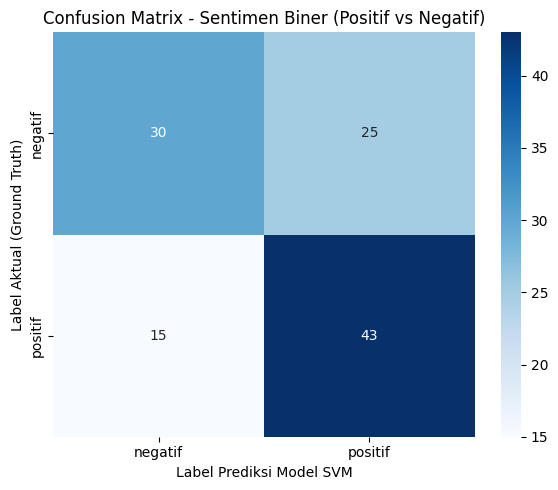


[SUKSES] 'svm_model.pkl' & 'tfidf_vectorizer.pkl' versi biner berhasil diamankan!


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 1. Load data berlabel Biner
df_labeled = pd.read_csv("tweets-data/genshin_tweets_labeled.csv")

# 2. Ekstraksi Fitur Teks menggunakan kombinasi Unigram & Bigram
# max_features diturunkan ke 1500 untuk mencegah Overfitting karena kelas netral sudah dihapus
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=1500)
X = vectorizer.fit_transform(df_labeled['clean_text'])
y = df_labeled['label']

# 3. Membagi data menjadi Latih (80%) dan Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih: {X_train.shape[0]} | Jumlah Data Uji: {X_test.shape[0]}")
print("Mencari kombinasi hyperparameter SVM terbaik dengan Grid Search (5-Fold)...")

# 4. Menentukan parameter grid SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

# 5. Melatih model dengan Grid Search CV
grid_search = GridSearchCV(SVC(random_state=42), param_grid, refit=True, cv=5, verbose=1)
grid_search.fit(X_train, y_train)

print("\n--- OPTIMASI SELESAI ---")
print(f"Hyperparameter Terbaik Hasil Grid Search: {grid_search.best_params_}")

# 6. Prediksi menggunakan model SVM terbaik
best_svm_model = grid_search.best_estimator_
y_pred = best_svm_model.predict(X_test)

# 7. Menampilkan Laporan Evaluasi Klasifikasi Biner
print("\nLaporan Klasifikasi (Classification Report):")
print(classification_report(y_test, y_pred))

# 8. Membuat Visualisasi Confusion Matrix Biner
cm = confusion_matrix(y_test, y_pred, labels=best_svm_model.classes_)

plt.figure(figsize=(6, 5))
# Menggunakan warna 'Blues' agar terlihat lebih bersih untuk 2 kelas
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_svm_model.classes_, 
            yticklabels=best_svm_model.classes_)
plt.title('Confusion Matrix - Sentimen Biner (Positif vs Negatif)')
plt.xlabel('Label Prediksi Model SVM')
plt.ylabel('Label Aktual (Ground Truth)')
plt.tight_layout()
plt.show()

# 9. Menyimpan Model & Vectorizer
joblib.dump(best_svm_model, 'svm_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("\n[SUKSES] 'svm_model.pkl' & 'tfidf_vectorizer.pkl' versi biner berhasil diamankan!")

In [14]:
import sklearn
print(sklearn.__version__)

1.7.2
